In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

Since we are doing DNS, which is non-dimensionalized for the parametric regime spanning $Re$, $Ca$ and $\theta$, there is a question of whether these non-dimensional parameters correspond to realistic values of density, viscosity, surface tension coefficient, film thickness and velocity. This code explores is there is a realistic scenario matching the non-dimensional parameters to the real-world parameters.

In [2]:
Reynolds_numbers = np.array(
    [5, 10, 20, 40, 60, 80, 100, 120],
    dtype=float,
)

Capillary_numbers = np.array(
    [0.001, 0.005, 0.0025, 0.01, 0.02, 0.04, 0.06, 0.1],
    dtype=float,
)

# Capillary_numbers = np.logspace(
#     np.log10(0.001),
#     np.log10(0.1),
#     10,
# )

angles_deg = np.array(
    [6.4, 30.0, 45.0, 60.0, 90.0],
    dtype=float,
)

gravity = 9.81

In [3]:
n_cases = (
    len(Reynolds_numbers)
    * len(Capillary_numbers)
    * len(angles_deg)
)

print(f"Number of Re-Ca-angle combinations: {n_cases}")

Number of Re-Ca-angle combinations: 320


In [4]:
realistic_ranges = {
    "rho": (750.0, 1250.0),       # kg/m^3
    "h0": (1.0e-4, 1.5e-3),      # m
    "mu": (1.0e-3, 2.0e-2),      # Pa s
    "sigma": (0.02, 0.08),        # N/m
    "velocity": (0.0, 0.3),       # m/s
}

In [5]:
pd.DataFrame(
    realistic_ranges,
    index=["minimum", "maximum"],
).T

,minimum,maximum
rho,750.0000,1250.0000
h0,0.0001,0.0015
mu,0.0010,0.0200
sigma,0.0200,0.0800
velocity,0.0000,0.3000


In [6]:
def calculate_properties(Re, Ca, angle_deg, rho, h0, gravity=9.81):
    """
    Calculate the dimensional properties required to realize
    a prescribed Re, Ca, and inclination angle.
    """

    theta = np.radians(angle_deg)

    mu = np.sqrt(
        rho**2
        * gravity
        * h0**3
        * np.sin(theta)
        / (3.0 * Re)
    )

    velocity = Re * mu / (rho * h0)

    sigma = mu * velocity / Ca

    return mu, velocity, sigma

In [7]:
# Test one dimensional realization

Re = 20.0
Ca = 0.01
angle_deg = 6.4

rho = 1072.0      # kg/m^3
h0 = 1.279e-3     # m

mu, velocity, sigma = calculate_properties(
    Re=Re,
    Ca=Ca,
    angle_deg=angle_deg,
    rho=rho,
    h0=h0,
    gravity=gravity,
)

print(f"Re       = {Re}")
print(f"Ca       = {Ca}")
print(f"angle    = {angle_deg} deg")
print()
print(f"rho      = {rho:.3f} kg/m^3")
print(f"h0       = {h0:.6e} m")
print(f"mu       = {mu:.6e} Pa s")
print(f"velocity = {velocity:.6e} m/s")
print(f"sigma    = {sigma:.6e} N/m")

Re       = 20.0
Ca       = 0.01
angle    = 6.4 deg

rho      = 1072.000 kg/m^3
h0       = 1.279000e-03 m
mu       = 6.619671e-03 Pa s
velocity = 9.656085e-02 m/s
sigma    = 6.392010e-02 N/m


In [8]:
def is_in_range(value, limits):
    return limits[0] <= value <= limits[1]


checks = {
    "rho": is_in_range(rho, realistic_ranges["rho"]),
    "h0": is_in_range(h0, realistic_ranges["h0"]),
    "mu": is_in_range(mu, realistic_ranges["mu"]),
    "sigma": is_in_range(sigma, realistic_ranges["sigma"]),
    "velocity": is_in_range(
        velocity,
        realistic_ranges["velocity"],
    ),
}

checks

{'rho': True,
 'h0': True,
 'mu': np.True_,
 'sigma': np.True_,
 'velocity': np.True_}

In [9]:
all(checks.values())

True

In [10]:
# Sampling resolution in dimensional space

number_of_rho_samples = 100
number_of_h0_samples = 500

rho_min, rho_max = realistic_ranges["rho"]
h0_min, h0_max = realistic_ranges["h0"]

rho_values = np.linspace(
    rho_min,
    rho_max,
    number_of_rho_samples,
)

h0_values = np.logspace(
    np.log10(h0_min),
    np.log10(h0_max),
    number_of_h0_samples,
)

rho_grid, h0_grid = np.meshgrid(
    rho_values,
    h0_values,
    indexing="ij",
)

rho_grid.shape, h0_grid.shape

((100, 500), (100, 500))

In [11]:
Re = 20.0
Ca = 0.01
angle_deg = 6.4

In [12]:
mu_grid, velocity_grid, sigma_grid = calculate_properties(
    Re=Re,
    Ca=Ca,
    angle_deg=angle_deg,
    rho=rho_grid,
    h0=h0_grid,
    gravity=gravity,
)

In [13]:
print(
    f"mu range:       "
    f"{mu_grid.min():.3e} to {mu_grid.max():.3e} Pa s"
)

print(
    f"velocity range: "
    f"{velocity_grid.min():.3e} to "
    f"{velocity_grid.max():.3e} m/s"
)

print(
    f"sigma range:    "
    f"{sigma_grid.min():.3e} to "
    f"{sigma_grid.max():.3e} N/m"
)

mu range:       1.013e-04 to 9.804e-03 Pa s
velocity range: 2.700e-02 to 1.046e-01 m/s
sigma range:    2.734e-04 to 1.025e-01 N/m


In [14]:
mu_min, mu_max = realistic_ranges["mu"]
sigma_min, sigma_max = realistic_ranges["sigma"]
velocity_min, velocity_max = realistic_ranges["velocity"]

mu_realistic = (
    (mu_grid >= mu_min)
    & (mu_grid <= mu_max)
)

sigma_realistic = (
    (sigma_grid >= sigma_min)
    & (sigma_grid <= sigma_max)
)

velocity_realistic = (
    (velocity_grid >= velocity_min)
    & (velocity_grid <= velocity_max)
)

feasible_mask = (
    mu_realistic
    & sigma_realistic
    & velocity_realistic
)

In [15]:
total_points = feasible_mask.size

print(
    f"Viscosity realistic: "
    f"{100 * mu_realistic.mean():.1f}%"
)

print(
    f"Surface tension realistic: "
    f"{100 * sigma_realistic.mean():.1f}%"
)

print(
    f"Velocity realistic: "
    f"{100 * velocity_realistic.mean():.1f}%"
)

print(
    f"All constraints satisfied: "
    f"{100 * feasible_mask.mean():.1f}%"
)

Viscosity realistic: 50.4%
Surface tension realistic: 24.5%
Velocity realistic: 100.0%
All constraints satisfied: 24.5%


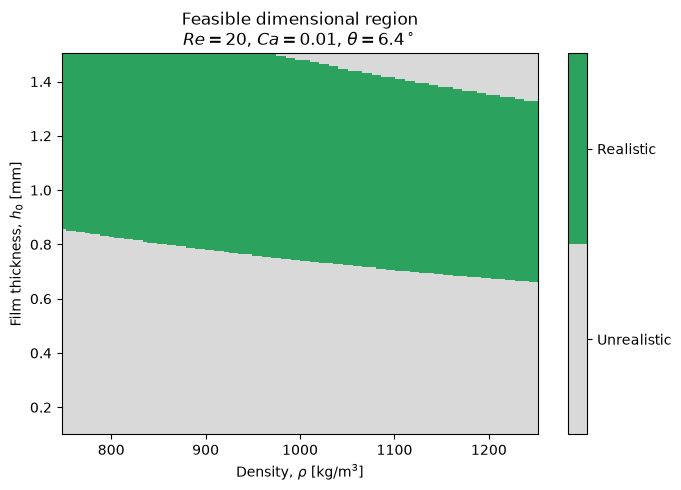

In [16]:
from matplotlib.colors import ListedColormap

feasibility_cmap = ListedColormap([
    "#d9d9d9",  # Unrealistic
    "#2ca25f",  # Realistic
])

plt.figure(figsize=(7, 5))

plt.pcolormesh(
    rho_values,
    h0_values * 1e3,
    feasible_mask.T.astype(int),
    shading="auto",
    cmap=feasibility_cmap,
    vmin=0,
    vmax=1,
)

plt.xlabel(r"Density, $\rho$ [kg/m$^3$]")
plt.ylabel(r"Film thickness, $h_0$ [mm]")

plt.title(
    rf"Feasible dimensional region"
    "\n"
    rf"$Re={Re:g}$, $Ca={Ca:g}$, "
    rf"$\theta={angle_deg:g}^\circ$"
)

cbar = plt.colorbar(ticks=[0.25, 0.75])
cbar.ax.set_yticklabels([
    "Unrealistic",
    "Realistic",
])

plt.tight_layout()
plt.show()

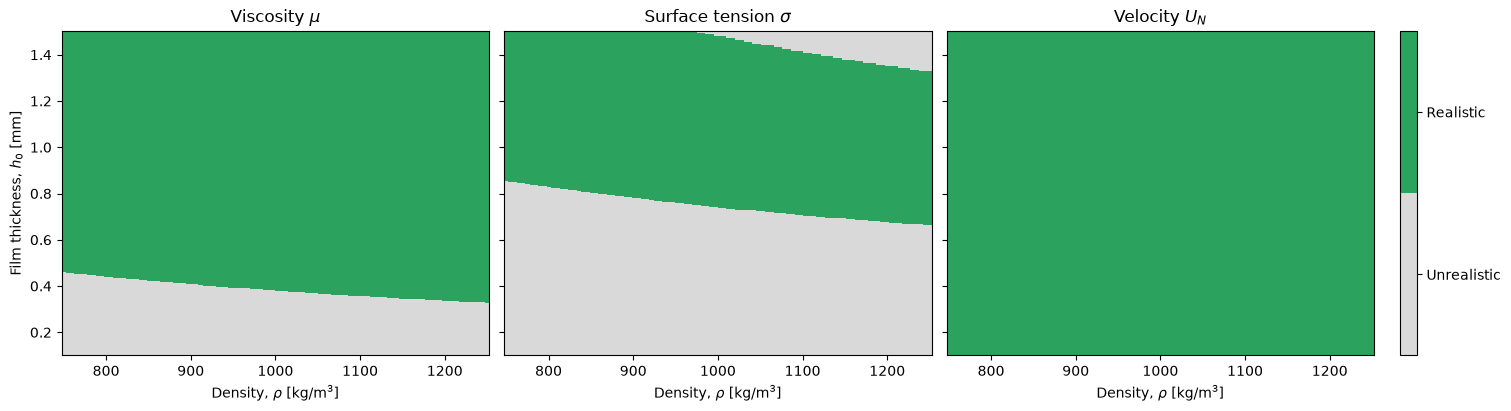

In [17]:
fig, ax = plt.subplots(
    1,
    3,
    figsize=(15, 4),
    sharey=True,
    constrained_layout=True,
)

masks = [
    mu_realistic,
    sigma_realistic,
    velocity_realistic,
]

titles = [
    r"Viscosity $\mu$",
    r"Surface tension $\sigma$",
    r"Velocity $U_N$",
]

for axis, mask, title in zip(ax, masks, titles):

    mesh = axis.pcolormesh(
        rho_values,
        h0_values * 1e3,
        mask.T.astype(int),
        shading="auto",
        cmap=feasibility_cmap,
        vmin=0,
        vmax=1,
    )

    axis.set_xlabel(
        r"Density, $\rho$ [kg/m$^3$]"
    )

    axis.set_title(title)

ax[0].set_ylabel(
    r"Film thickness, $h_0$ [mm]"
)

cbar = fig.colorbar(
    mesh,
    ax=ax,
    ticks=[0.25, 0.75],
    pad=0.02,
)

cbar.ax.set_yticklabels([
    "Unrealistic",
    "Realistic",
])

plt.show()

In [18]:
def evaluate_case(
    Re,
    Ca,
    angle_deg,
    realistic_ranges,
    number_of_rho_samples=100,
    number_of_h0_samples=500,
    gravity=9.81,
):
    """
    Evaluate dimensional feasibility for one (Re, Ca, angle) case.

    Returns
    -------
    result : dict
        Contains the sampled grids, calculated properties,
        feasibility masks, and summary statistics.
    """

    # Sampling ranges
    rho_min, rho_max = realistic_ranges["rho"]
    h0_min, h0_max = realistic_ranges["h0"]

    rho_values = np.linspace(
        rho_min,
        rho_max,
        number_of_rho_samples,
    )

    h0_values = np.logspace(
        np.log10(h0_min),
        np.log10(h0_max),
        number_of_h0_samples,
    )

    rho_grid, h0_grid = np.meshgrid(
        rho_values,
        h0_values,
        indexing="ij",
    )

    # Dimensional properties required for this Re-Ca-angle
    mu_grid, velocity_grid, sigma_grid = calculate_properties(
        Re=Re,
        Ca=Ca,
        angle_deg=angle_deg,
        rho=rho_grid,
        h0=h0_grid,
        gravity=gravity,
    )

    # Realistic ranges
    mu_min, mu_max = realistic_ranges["mu"]
    sigma_min, sigma_max = realistic_ranges["sigma"]
    velocity_min, velocity_max = realistic_ranges["velocity"]

    # Individual feasibility masks
    mu_realistic = (
        (mu_grid >= mu_min)
        & (mu_grid <= mu_max)
    )

    sigma_realistic = (
        (sigma_grid >= sigma_min)
        & (sigma_grid <= sigma_max)
    )

    velocity_realistic = (
        (velocity_grid >= velocity_min)
        & (velocity_grid <= velocity_max)
    )

    # Combined feasibility
    feasible_mask = (
        mu_realistic
        & sigma_realistic
        & velocity_realistic
    )

    return {
        "Re": Re,
        "Ca": Ca,
        "angle_deg": angle_deg,

        "rho_values": rho_values,
        "h0_values": h0_values,

        "rho_grid": rho_grid,
        "h0_grid": h0_grid,

        "mu_grid": mu_grid,
        "velocity_grid": velocity_grid,
        "sigma_grid": sigma_grid,

        "mu_realistic": mu_realistic,
        "sigma_realistic": sigma_realistic,
        "velocity_realistic": velocity_realistic,
        "feasible_mask": feasible_mask,

        "is_feasible": np.any(feasible_mask),

        "mu_fraction": mu_realistic.mean(),
        "sigma_fraction": sigma_realistic.mean(),
        "velocity_fraction": velocity_realistic.mean(),
        "feasible_fraction": feasible_mask.mean(),
    }

In [19]:
result = evaluate_case(
    Re=20.0,
    Ca=0.01,
    angle_deg=6.4,
    realistic_ranges=realistic_ranges,
)

In [20]:
print(
    f"Feasible: {result['is_feasible']}"
)

print(
    f"Viscosity realistic: "
    f"{100 * result['mu_fraction']:.1f}%"
)

print(
    f"Surface tension realistic: "
    f"{100 * result['sigma_fraction']:.1f}%"
)

print(
    f"Velocity realistic: "
    f"{100 * result['velocity_fraction']:.1f}%"
)

print(
    f"All constraints satisfied: "
    f"{100 * result['feasible_fraction']:.1f}%"
)

Feasible: True
Viscosity realistic: 50.4%
Surface tension realistic: 24.5%
Velocity realistic: 100.0%
All constraints satisfied: 24.5%


In [21]:
result["is_feasible"]

np.True_

In [22]:
mask = result["feasible_mask"]

if np.any(mask):

    rho_feasible = result["rho_grid"][mask]
    h0_feasible = result["h0_grid"][mask]
    mu_feasible = result["mu_grid"][mask]
    velocity_feasible = result["velocity_grid"][mask]
    sigma_feasible = result["sigma_grid"][mask]

    print(
        f"rho:      {rho_feasible.min():.1f} "
        f"to {rho_feasible.max():.1f} kg/m^3"
    )

    print(
        f"h0:       {1e3*h0_feasible.min():.3f} "
        f"to {1e3*h0_feasible.max():.3f} mm"
    )

    print(
        f"mu:       {mu_feasible.min():.3e} "
        f"to {mu_feasible.max():.3e} Pa s"
    )

    print(
        f"velocity: {velocity_feasible.min():.3e} "
        f"to {velocity_feasible.max():.3e} m/s"
    )

    print(
        f"sigma:    {sigma_feasible.min():.3e} "
        f"to {sigma_feasible.max():.3e} N/m"
    )

else:
    print("No realistic dimensional realization exists.")

rho:      750.0 to 1250.0 kg/m^3
h0:       0.665 to 1.500 mm
mu:       2.540e-03 to 8.130e-03 Pa s
velocity: 6.961e-02 to 1.046e-01 m/s
sigma:    2.000e-02 to 7.999e-02 N/m


In [23]:
results = []

for angle_deg in angles_deg:
    for Re in Reynolds_numbers:
        for Ca in Capillary_numbers:

            result = evaluate_case(
                Re=Re,
                Ca=Ca,
                angle_deg=angle_deg,
                realistic_ranges=realistic_ranges,
                number_of_rho_samples=100,
                number_of_h0_samples=500,
                gravity=gravity,
            )

            results.append({
                "Re": Re,
                "Ca": Ca,
                "angle_deg": angle_deg,
                "is_feasible": result["is_feasible"],
                "feasible_fraction": result["feasible_fraction"],
                "mu_fraction": result["mu_fraction"],
                "sigma_fraction": result["sigma_fraction"],
                "velocity_fraction": result["velocity_fraction"],
            })

parameter_df = pd.DataFrame(results)

In [24]:
parameter_df.head(10)

,Re,Ca,angle_deg,is_feasible,feasible_fraction,mu_fraction,sigma_fraction,velocity_fraction
0,5.0,0.0010,6.4,True,0.24616,0.67468,0.25550,1.0
1,5.0,0.0050,6.4,True,0.25544,0.67468,0.25544,1.0
2,5.0,0.0025,6.4,True,0.25554,0.67468,0.25554,1.0
3,5.0,0.0100,6.4,True,0.24524,0.67468,0.24524,1.0
4,5.0,0.0200,6.4,True,0.13132,0.67468,0.13132,1.0
5,5.0,0.0400,6.4,True,0.01372,0.67468,0.01372,1.0
6,5.0,0.0600,6.4,False,0.00000,0.67468,0.00000,1.0
7,5.0,0.1000,6.4,False,0.00000,0.67468,0.00000,1.0
8,10.0,0.0010,6.4,True,0.16164,0.58946,0.25550,1.0
9,10.0,0.0050,6.4,True,0.25544,0.58946,0.25544,1.0


In [25]:
parameter_df.shape

(320, 8)

In [26]:
print(
    f"Feasible cases: "
    f"{parameter_df['is_feasible'].sum()}"
)

print(
    f"Infeasible cases: "
    f"{(~parameter_df['is_feasible']).sum()}"
)

Feasible cases: 211
Infeasible cases: 109


In [27]:
from matplotlib.colors import ListedColormap

feasibility_cmap = ListedColormap([
    "#d9d9d9",  # Unrealistic
    "#2ca25f",  # Realistic
])

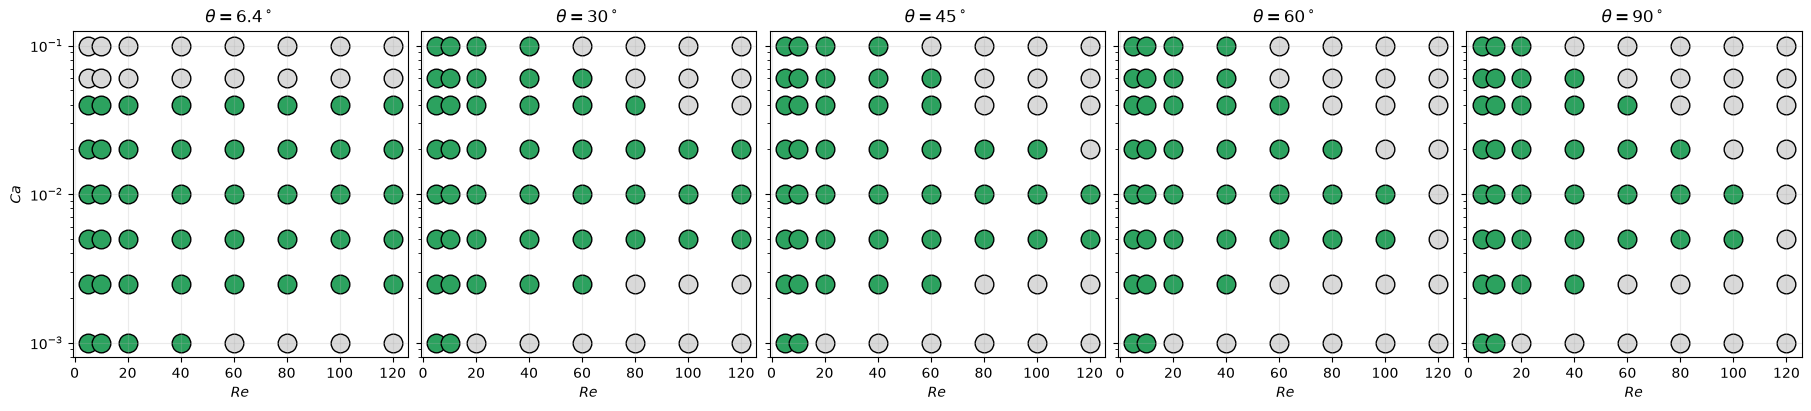

In [28]:
fig, axes = plt.subplots(
    1,
    len(angles_deg),
    figsize=(18, 4),
    sharey=True,
    constrained_layout=True,
)

for ax, angle_deg in zip(axes, angles_deg):

    angle_df = parameter_df[
        parameter_df["angle_deg"] == angle_deg
    ]

    for _, row in angle_df.iterrows():

        value = int(row["is_feasible"])

        ax.scatter(
            row["Re"],
            row["Ca"],
            c=[value],
            cmap=feasibility_cmap,
            vmin=0,
            vmax=1,
            s=180,
            edgecolor="black",
        )

    ax.set_title(
        rf"$\theta = {angle_deg:g}^\circ$"
    )

    ax.set_xlabel(r"$Re$")
    ax.set_yscale("log")
    ax.grid(alpha=0.25)

axes[0].set_ylabel(r"$Ca$")

plt.show()

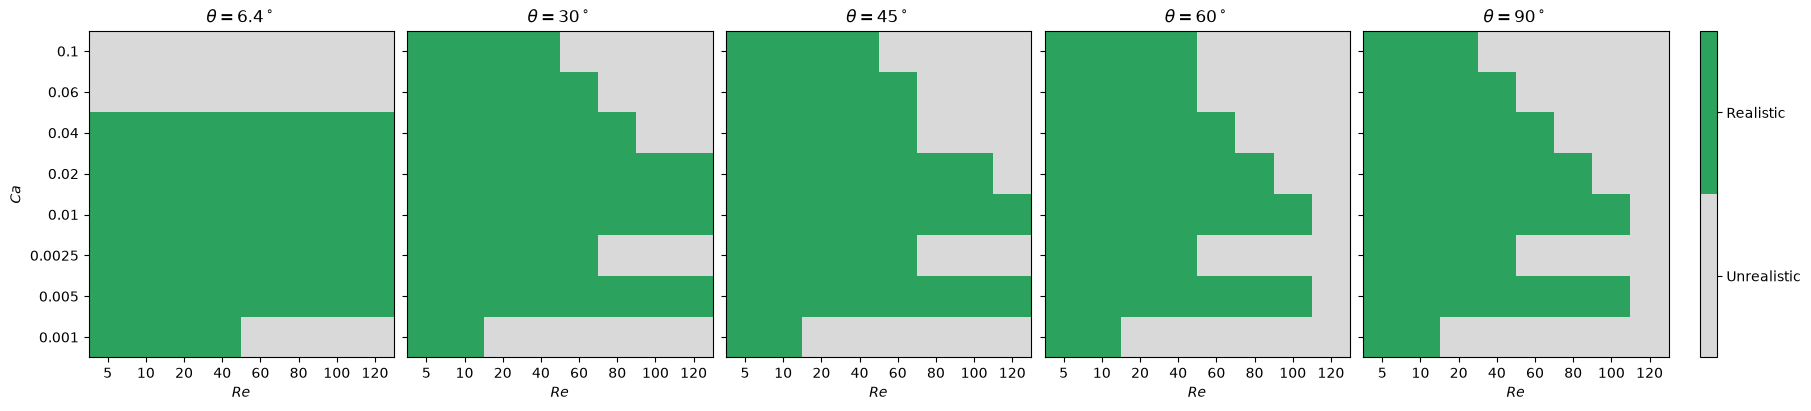

In [29]:
fig, axes = plt.subplots(
    1,
    len(angles_deg),
    figsize=(18, 4),
    sharey=True,
    constrained_layout=True,
)

for ax, angle_deg in zip(axes, angles_deg):

    angle_df = parameter_df[
        parameter_df["angle_deg"] == angle_deg
    ]

    feasibility_matrix = (
        angle_df
        .pivot(
            index="Ca",
            columns="Re",
            values="is_feasible",
        )
        .reindex(
            index=Capillary_numbers,
            columns=Reynolds_numbers,
        )
    )

    image = ax.imshow(
        feasibility_matrix.astype(int),
        origin="lower",
        aspect="auto",
        cmap=feasibility_cmap,
        vmin=0,
        vmax=1,
    )

    ax.set_xticks(
        np.arange(len(Reynolds_numbers))
    )

    ax.set_xticklabels(
        Reynolds_numbers.astype(int)
    )

    ax.set_yticks(
        np.arange(len(Capillary_numbers))
    )

    ax.set_yticklabels(
        Capillary_numbers
    )

    ax.set_xlabel(r"$Re$")

    ax.set_title(
        rf"$\theta={angle_deg:g}^\circ$"
    )

axes[0].set_ylabel(r"$Ca$")

cbar = fig.colorbar(
    image,
    ax=axes,
    ticks=[0.25, 0.75],
    pad=0.02,
)

cbar.ax.set_yticklabels([
    "Unrealistic",
    "Realistic",
])

plt.show()

Now, checking with reference fluids.

In [30]:
reference_fluids = {

    # ---------------------------------------------------------
    # Water
    # ---------------------------------------------------------

    "water": {
        "rho": 998.0,
        "mu": 1.00e-3,
        "sigma": 0.072,
    },

    # ---------------------------------------------------------
    # Water-glycerol mixtures
    # Approximate properties near 20 C
    # Naming refers to glycerol mass fraction
    # ---------------------------------------------------------

    "glycerol_20wt": {
        "rho": 1047.0,
        "mu": 1.84e-3,
        "sigma": 0.0717,
    },

    "glycerol_40wt": {
        "rho": 1100.0,
        "mu": 3.63e-3,
        "sigma": 0.0700,
    },

    "glycerol_60wt": {
        "rho": 1156.0,
        "mu": 11.67e-3,
        "sigma": 0.0685,
    },

    # ---------------------------------------------------------
    # Your aqueous working mixture
    # ---------------------------------------------------------

    "aqueous_mixture": {
        "rho": 1072.0,
        "mu": 6.73e-3,
        "sigma": 0.067,
    },

    # ---------------------------------------------------------
    # Alcohols / aqueous alcohols
    # ---------------------------------------------------------

    "ethanol": {
        "rho": 789.0,
        "mu": 1.20e-3,
        "sigma": 0.022,
    },

    # ---------------------------------------------------------
    # Hydrocarbon liquids
    # ---------------------------------------------------------

    "kerosene": {
        "rho": 814.0,
        "mu": 1.90e-3,
        "sigma": 0.029,
    },

    # ---------------------------------------------------------
    # Silicone oils
    #
    # Approximate PDMS properties. These should eventually
    # be replaced with manufacturer-specific data.
    # ---------------------------------------------------------

    "silicone_oil_5cSt": {
        "rho": 915.0,
        "mu": 4.6e-3,
        "sigma": 0.020,
    },

    "silicone_oil_10cSt": {
        "rho": 935.0,
        "mu": 9.4e-3,
        "sigma": 0.020,
    },

    "silicone_oil_20cSt": {
        "rho": 950.0,
        "mu": 19.0e-3,
        "sigma": 0.021,
    },
}

In [31]:
fluid_tolerances = {
    "rho": 0.05,       # ±5%
    "mu": 0.15,        # ±15%
    "sigma": 0.10,     # ±10%
}

In [32]:
def match_case_to_fluid(
    result,
    reference_fluids,
    fluid_tolerances,
):
    """
    Find the best reference-fluid match among the feasible
    dimensional realizations for one (Re, Ca, angle) case.
    """

    feasible_mask = result["feasible_mask"]

    # No feasible dimensional realization
    if not np.any(feasible_mask):
        return {
            "matched": False,
            "fluid": None,
            "distance": np.nan,
            "rho": np.nan,
            "h0": np.nan,
            "mu": np.nan,
            "velocity": np.nan,
            "sigma": np.nan,
        }

    # Extract only feasible points
    rho = result["rho_grid"][feasible_mask]
    h0 = result["h0_grid"][feasible_mask]
    mu = result["mu_grid"][feasible_mask]
    velocity = result["velocity_grid"][feasible_mask]
    sigma = result["sigma_grid"][feasible_mask]

    best_match = None
    best_distance = np.inf

    for fluid_name, fluid in reference_fluids.items():

        rho_error = np.abs(rho - fluid["rho"]) / fluid["rho"]
        mu_error = np.abs(mu - fluid["mu"]) / fluid["mu"]
        sigma_error = (
            np.abs(sigma - fluid["sigma"])
            / fluid["sigma"]
        )

        # Require every property to fall inside tolerance
        valid = (
            (rho_error <= fluid_tolerances["rho"])
            & (mu_error <= fluid_tolerances["mu"])
            & (sigma_error <= fluid_tolerances["sigma"])
        )

        if not np.any(valid):
            continue

        # Normalized distance in property space
        distance = np.sqrt(
            (rho_error / fluid_tolerances["rho"])**2
            + (mu_error / fluid_tolerances["mu"])**2
            + (sigma_error / fluid_tolerances["sigma"])**2
        )

        distance[~valid] = np.inf

        idx = np.argmin(distance)

        if distance[idx] < best_distance:

            best_distance = distance[idx]

            best_match = {
                "matched": True,
                "fluid": fluid_name,
                "distance": distance[idx],
                "rho": rho[idx],
                "h0": h0[idx],
                "mu": mu[idx],
                "velocity": velocity[idx],
                "sigma": sigma[idx],
            }

    if best_match is None:
        return {
            "matched": False,
            "fluid": None,
            "distance": np.nan,
            "rho": np.nan,
            "h0": np.nan,
            "mu": np.nan,
            "velocity": np.nan,
            "sigma": np.nan,
        }

    return best_match

In [33]:
result = evaluate_case(
    Re=20.0,
    Ca=0.01,
    angle_deg=6.4,
    realistic_ranges=realistic_ranges,
)

match = match_case_to_fluid(
    result,
    reference_fluids,
    fluid_tolerances,
)

match

{'matched': True,
 'fluid': 'aqueous_mixture',
 'distance': np.float64(0.12528993145037545),
 'rho': np.float64(1073.2323232323233),
 'h0': np.float64(0.001302602642843292),
 'mu': np.float64(0.0068115739442762505),
 'velocity': np.float64(0.09744774014784492),
 'sigma': np.float64(0.06637724877196631)}

In [34]:
results = []

for angle_deg in angles_deg:
    for Re in Reynolds_numbers:
        for Ca in Capillary_numbers:

            result = evaluate_case(
                Re=Re,
                Ca=Ca,
                angle_deg=angle_deg,
                realistic_ranges=realistic_ranges,
                number_of_rho_samples=100,
                number_of_h0_samples=500,
                gravity=gravity,
            )

            match = match_case_to_fluid(
                result,
                reference_fluids,
                fluid_tolerances,
            )

            results.append({
                "Re": Re,
                "Ca": Ca,
                "angle_deg": angle_deg,

                "is_feasible": result["is_feasible"],
                "feasible_fraction": result["feasible_fraction"],

                "matched_fluid": match["fluid"],
                "fluid_match": match["matched"],
                "match_distance": match["distance"],

                "rho": match["rho"],
                "h0": match["h0"],
                "mu": match["mu"],
                "velocity": match["velocity"],
                "sigma": match["sigma"],
            })

parameter_df = pd.DataFrame(results)

In [35]:
parameter_df[
    [
        "Re",
        "Ca",
        "angle_deg",
        "is_feasible",
        "matched_fluid",
        "h0",
        "velocity",
    ]
]

,Re,Ca,angle_deg,is_feasible,matched_fluid,h0,velocity
0,5.0,0.0010,6.4,True,ethanol,0.000283,0.022730
1,5.0,0.0050,6.4,True,aqueous_mixture,0.000896,0.040404
2,5.0,0.0025,6.4,True,NaN,NaN,NaN
3,5.0,0.0100,6.4,True,glycerol_60wt,0.001227,0.047291
4,5.0,0.0200,6.4,True,silicone_oil_10cSt,0.001089,0.044551
...,...,...,...,...,...,...,...
315,120.0,0.0100,90.0,False,NaN,NaN,NaN
316,120.0,0.0200,90.0,False,NaN,NaN,NaN
317,120.0,0.0400,90.0,False,NaN,NaN,NaN
318,120.0,0.0600,90.0,False,NaN,NaN,NaN


Instead of directly matching fluids, let's do a tolerance based matching, for the case of mixtures.

In [36]:
def evaluate_fluid(
    Re,
    angle_deg,
    fluid,
    gravity=9.81,
):
    """
    Determine the falling-film conditions produced by a known fluid
    at prescribed Reynolds number and inclination angle.

    Parameters
    ----------
    Re : float
        Target Reynolds number.

    angle_deg : float
        Inclination angle in degrees.

    fluid : dict
        Dictionary containing:
            rho   : density [kg/m^3]
            mu    : dynamic viscosity [Pa s]
            sigma : surface tension [N/m]

    Returns
    -------
    dict
        h0       : required Nusselt film thickness [m]
        velocity : Nusselt mean velocity [m/s]
        Ca       : resulting Capillary number
    """

    rho = fluid["rho"]
    mu = fluid["mu"]
    sigma = fluid["sigma"]

    theta = np.radians(angle_deg)

    # Film thickness required to achieve the prescribed Re
    h0 = (
        3.0 * Re * mu**2
        / (
            rho**2
            * gravity
            * np.sin(theta)
        )
    ) ** (1.0 / 3.0)

    # Corresponding Nusselt mean velocity
    velocity = (
        Re * mu
        / (rho * h0)
    )

    # Capillary number produced by this fluid
    Ca = (
        mu * velocity
        / sigma
    )

    return {
        "h0": h0,
        "velocity": velocity,
        "Ca": Ca,
    }

In [37]:
fluid = reference_fluids["aqueous_mixture"]

fluid_result = evaluate_fluid(
    Re=20.0,
    angle_deg=6.4,
    fluid=fluid,
)

fluid_result

{'h0': np.float64(0.0012931720813634867),
 'velocity': np.float64(0.09709434908318657),
 'Ca': np.float64(0.009752909989997694)}

In [38]:
print(
    f"h0       = "
    f"{fluid_result['h0'] * 1e3:.3f} mm"
)

print(
    f"velocity = "
    f"{fluid_result['velocity']:.4f} m/s"
)

print(
    f"Ca       = "
    f"{fluid_result['Ca']:.5f}"
)

h0       = 1.293 mm
velocity = 0.0971 m/s
Ca       = 0.00975


In [39]:
def compare_fluids(
    Re,
    target_Ca,
    angle_deg,
    reference_fluids,
):
    """
    Compare all reference fluids against a target
    (Re, Ca, angle) combination.
    """

    rows = []

    for fluid_name, fluid in reference_fluids.items():

        result = evaluate_fluid(
            Re=Re,
            angle_deg=angle_deg,
            fluid=fluid,
        )

        # Relative error in Ca
        Ca_error = (
            abs(result["Ca"] - target_Ca)
            / target_Ca
        )

        rows.append({
            "fluid": fluid_name,

            "rho": fluid["rho"],
            "mu": fluid["mu"],
            "sigma": fluid["sigma"],

            "h0": result["h0"],
            "velocity": result["velocity"],
            "Ca_actual": result["Ca"],

            "Ca_target": target_Ca,
            "Ca_error": Ca_error,
        })

    fluid_df = pd.DataFrame(rows)

    return fluid_df.sort_values(
        "Ca_error"
    ).reset_index(drop=True)

In [40]:
fluid_df = compare_fluids(
    Re=20.0,
    target_Ca=0.01,
    angle_deg=6.4,
    reference_fluids=reference_fluids,
)

fluid_df

,fluid,rho,mu,sigma,h0,velocity,Ca_actual,Ca_target,Ca_error
0,aqueous_mixture,1072.0,0.00673,0.0670,0.001293,0.097094,0.009753,0.01,0.024709
1,kerosene,814.0,0.00190,0.0290,0.000669,0.069817,0.004574,0.01,0.542576
2,glycerol_40wt,1100.0,0.00363,0.0700,0.000842,0.078360,0.004064,0.01,0.593650
3,ethanol,789.0,0.00120,0.0220,0.000503,0.060528,0.003302,0.01,0.669848
4,glycerol_20wt,1047.0,0.00184,0.0717,0.000553,0.063515,0.001630,0.01,0.837004
5,water,998.0,0.00100,0.0720,0.000381,0.052668,0.000731,0.01,0.926851
6,glycerol_60wt,1156.0,0.01167,0.0685,0.001775,0.113752,0.019379,0.01,0.937932
7,silicone_oil_5cSt,915.0,0.00460,0.0200,0.001115,0.090164,0.020738,0.01,1.073770
8,silicone_oil_10cSt,935.0,0.00940,0.0200,0.001770,0.113595,0.053390,0.01,4.338966
9,silicone_oil_20cSt,950.0,0.01900,0.0210,0.002800,0.142867,0.129260,0.01,11.926020


In [41]:
display_df = fluid_df.copy()

display_df["h0_mm"] = (
    1000 * display_df["h0"]
)

display_df["Ca_error_percent"] = (
    100 * display_df["Ca_error"]
)

display_df[
    [
        "fluid",
        "h0_mm",
        "velocity",
        "Ca_actual",
        "Ca_error_percent",
    ]
]

,fluid,h0_mm,velocity,Ca_actual,Ca_error_percent
0,aqueous_mixture,1.293172,0.097094,0.009753,2.470900
1,kerosene,0.668645,0.069817,0.004574,54.257574
2,glycerol_40wt,0.842271,0.078360,0.004064,59.364985
3,ethanol,0.502550,0.060528,0.003302,66.984807
4,glycerol_20wt,0.553380,0.063515,0.001630,83.700426
5,water,0.380501,0.052668,0.000731,92.685053
6,glycerol_60wt,1.774945,0.113752,0.019379,93.793179
7,silicone_oil_5cSt,1.115152,0.090164,0.020738,107.377011
8,silicone_oil_10cSt,1.770056,0.113595,0.053390,433.896574
9,silicone_oil_20cSt,2.799816,0.142867,0.129260,1192.602028


In [42]:
def compare_fluids(
    Re,
    target_Ca,
    angle_deg,
    reference_fluids,
    realistic_ranges,
):
    """
    Compare known fluids against a target
    (Re, Ca, angle) combination.
    """

    rows = []

    for fluid_name, fluid in reference_fluids.items():

        result = evaluate_fluid(
            Re=Re,
            angle_deg=angle_deg,
            fluid=fluid,
        )

        Ca_error = (
            abs(result["Ca"] - target_Ca)
            / target_Ca
        )

        h0_realistic = (
            realistic_ranges["h0"][0]
            <= result["h0"]
            <= realistic_ranges["h0"][1]
        )

        velocity_realistic = (
            realistic_ranges["velocity"][0]
            <= result["velocity"]
            <= realistic_ranges["velocity"][1]
        )

        experimentally_realistic = (
            h0_realistic
            and velocity_realistic
        )

        rows.append({
            "fluid": fluid_name,

            "rho": fluid["rho"],
            "mu": fluid["mu"],
            "sigma": fluid["sigma"],

            "h0": result["h0"],
            "velocity": result["velocity"],
            "Ca_actual": result["Ca"],

            "Ca_target": target_Ca,
            "Ca_error": Ca_error,

            "h0_realistic": h0_realistic,
            "velocity_realistic": velocity_realistic,
            "experimentally_realistic": experimentally_realistic,
        })

    return (
        pd.DataFrame(rows)
        .sort_values("Ca_error")
        .reset_index(drop=True)
    )

In [43]:
fluid_df = compare_fluids(
    Re=20.0,
    target_Ca=0.01,
    angle_deg=6.4,
    reference_fluids=reference_fluids,
    realistic_ranges=realistic_ranges,
)

fluid_df[
    [
        "fluid",
        "h0",
        "velocity",
        "Ca_actual",
        "Ca_error",
        "experimentally_realistic",
    ]
]

,fluid,h0,velocity,Ca_actual,Ca_error,experimentally_realistic
0,aqueous_mixture,0.001293,0.097094,0.009753,0.024709,True
1,kerosene,0.000669,0.069817,0.004574,0.542576,True
2,glycerol_40wt,0.000842,0.078360,0.004064,0.593650,True
3,ethanol,0.000503,0.060528,0.003302,0.669848,True
4,glycerol_20wt,0.000553,0.063515,0.001630,0.837004,True
5,water,0.000381,0.052668,0.000731,0.926851,True
6,glycerol_60wt,0.001775,0.113752,0.019379,0.937932,False
7,silicone_oil_5cSt,0.001115,0.090164,0.020738,1.073770,True
8,silicone_oil_10cSt,0.001770,0.113595,0.053390,4.338966,False
9,silicone_oil_20cSt,0.002800,0.142867,0.129260,11.926020,False


In [44]:
Ca_tolerance = 0.20

In [45]:
fluid_match_results = []

for angle_deg in angles_deg:
    for Re in Reynolds_numbers:
        for Ca in Capillary_numbers:

            fluid_df = compare_fluids(
                Re=Re,
                target_Ca=Ca,
                angle_deg=angle_deg,
                reference_fluids=reference_fluids,
                realistic_ranges=realistic_ranges,
            )

            # Require both:
            # 1. realistic h0 and velocity
            # 2. Ca within the selected tolerance
            fluid_df["Ca_match"] = (
                fluid_df["Ca_error"] <= Ca_tolerance
            )

            fluid_df["valid_match"] = (
                fluid_df["Ca_match"]
                & fluid_df["experimentally_realistic"]
            )

            valid_fluids = fluid_df[
                fluid_df["valid_match"]
            ]

            if len(valid_fluids) > 0:

                # Already sorted by Ca_error,
                # so first row is the best match
                best = valid_fluids.iloc[0]

                fluid_match_results.append({
                    "Re": Re,
                    "Ca_target": Ca,
                    "angle_deg": angle_deg,

                    "matched": True,
                    "fluid": best["fluid"],

                    "Ca_actual": best["Ca_actual"],
                    "Ca_error": best["Ca_error"],

                    "rho": best["rho"],
                    "mu": best["mu"],
                    "sigma": best["sigma"],

                    "h0": best["h0"],
                    "velocity": best["velocity"],
                })

            else:

                fluid_match_results.append({
                    "Re": Re,
                    "Ca_target": Ca,
                    "angle_deg": angle_deg,

                    "matched": False,
                    "fluid": None,

                    "Ca_actual": np.nan,
                    "Ca_error": np.nan,

                    "rho": np.nan,
                    "mu": np.nan,
                    "sigma": np.nan,

                    "h0": np.nan,
                    "velocity": np.nan,
                })


fluid_match_df = pd.DataFrame(
    fluid_match_results
)

In [46]:
fluid_match_df.head(15)

,Re,Ca_target,angle_deg,matched,fluid,Ca_actual,Ca_error,rho,mu,sigma,h0,velocity
0,5.0,0.0010,6.4,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5.0,0.0050,6.4,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5.0,0.0025,6.4,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5.0,0.0100,6.4,True,silicone_oil_5cSt,0.008230,0.177024,915.0,0.00460,0.0200,0.000703,0.035782
4,5.0,0.0200,6.4,True,silicone_oil_10cSt,0.021188,0.059385,935.0,0.00940,0.0200,0.001115,0.045080
5,5.0,0.0400,6.4,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,5.0,0.0600,6.4,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,5.0,0.1000,6.4,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,10.0,0.0010,6.4,True,glycerol_20wt,0.001027,0.026809,1047.0,0.00184,0.0717,0.000439,0.040012
9,10.0,0.0050,6.4,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
fluid_match_df[
    [
        "Re",
        "Ca_target",
        "angle_deg",
        "matched",
        "fluid",
        "Ca_actual",
        "Ca_error",
        "h0",
        "velocity",
    ]
]

,Re,Ca_target,angle_deg,matched,fluid,Ca_actual,Ca_error,h0,velocity
0,5.0,0.0010,6.4,False,NaN,NaN,NaN,NaN,NaN
1,5.0,0.0050,6.4,False,NaN,NaN,NaN,NaN,NaN
2,5.0,0.0025,6.4,False,NaN,NaN,NaN,NaN,NaN
3,5.0,0.0100,6.4,True,silicone_oil_5cSt,0.008230,0.177024,0.000703,0.035782
4,5.0,0.0200,6.4,True,silicone_oil_10cSt,0.021188,0.059385,0.001115,0.045080
...,...,...,...,...,...,...,...,...,...
315,120.0,0.0100,90.0,False,NaN,NaN,NaN,NaN,NaN
316,120.0,0.0200,90.0,False,NaN,NaN,NaN,NaN,NaN
317,120.0,0.0400,90.0,False,NaN,NaN,NaN,NaN,NaN
318,120.0,0.0600,90.0,False,NaN,NaN,NaN,NaN,NaN


In [48]:
fluid_match_df["Ca_error_percent"] = (
    100 * fluid_match_df["Ca_error"]
)

fluid_match_df["h0_mm"] = (
    1000 * fluid_match_df["h0"]
)

In [49]:
fluid_match_df[
    [
        "Re",
        "Ca_target",
        "angle_deg",
        "fluid",
        "Ca_actual",
        "Ca_error_percent",
        "h0_mm",
        "velocity",
    ]
]

,Re,Ca_target,angle_deg,fluid,Ca_actual,Ca_error_percent,h0_mm,velocity
0,5.0,0.0010,6.4,NaN,NaN,NaN,NaN,NaN
1,5.0,0.0050,6.4,NaN,NaN,NaN,NaN,NaN
2,5.0,0.0025,6.4,NaN,NaN,NaN,NaN,NaN
3,5.0,0.0100,6.4,silicone_oil_5cSt,0.008230,17.702379,0.702502,0.035782
4,5.0,0.0200,6.4,silicone_oil_10cSt,0.021188,5.938498,1.115065,0.045080
...,...,...,...,...,...,...,...,...
315,120.0,0.0100,90.0,NaN,NaN,NaN,NaN,NaN
316,120.0,0.0200,90.0,NaN,NaN,NaN,NaN,NaN
317,120.0,0.0400,90.0,NaN,NaN,NaN,NaN,NaN
318,120.0,0.0600,90.0,NaN,NaN,NaN,NaN,NaN


In [50]:
print(
    "Matched cases:",
    fluid_match_df["matched"].sum()
)

print(
    "Unmatched cases:",
    (~fluid_match_df["matched"]).sum()
)

Matched cases: 94
Unmatched cases: 226


In [51]:
fluid_match_df["fluid"].value_counts(
    dropna=False
)

fluid
NaN                   226
glycerol_20wt          15
silicone_oil_10cSt     14
silicone_oil_5cSt      12
water                  11
ethanol                11
kerosene                9
aqueous_mixture         8
glycerol_40wt           7
silicone_oil_20cSt      4
glycerol_60wt           3
Name: count, dtype: int64

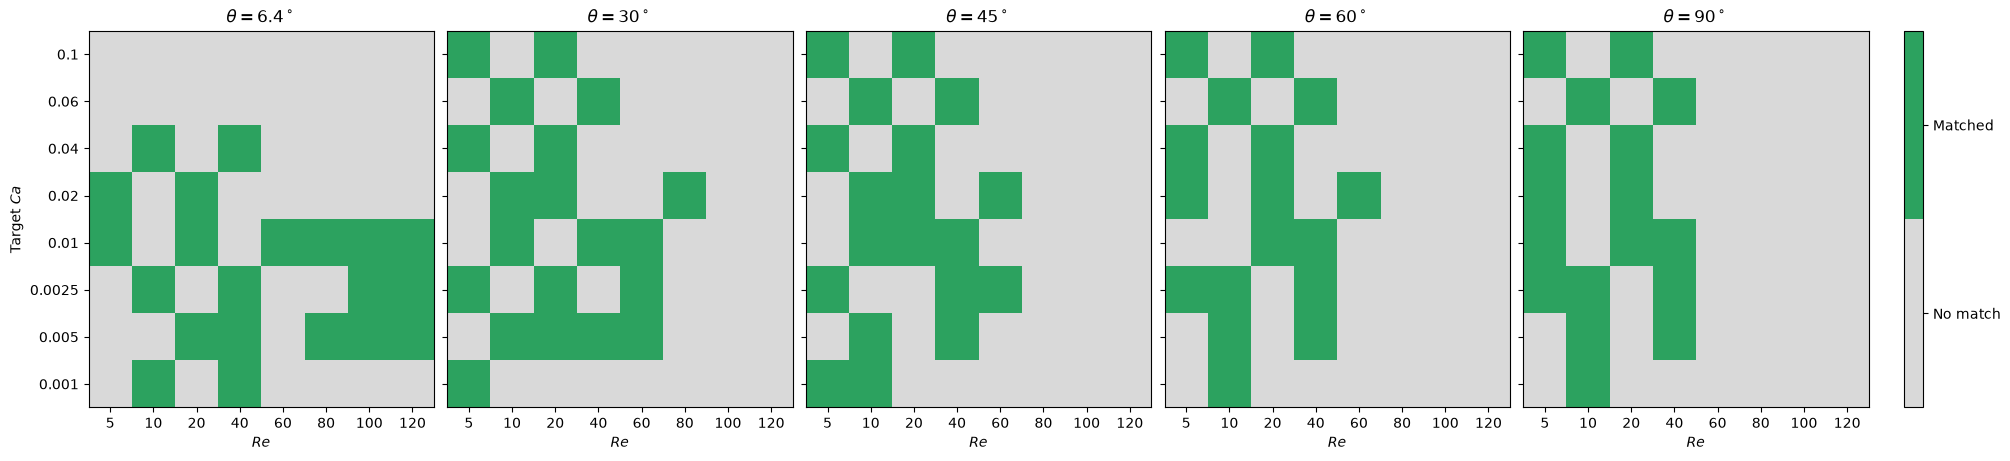

In [52]:
fig, axes = plt.subplots(
    1,
    len(angles_deg),
    figsize=(20, 4.5),
    sharey=True,
    constrained_layout=True,
)

for ax, angle_deg in zip(
    axes,
    angles_deg,
):

    angle_df = fluid_match_df[
        fluid_match_df["angle_deg"] == angle_deg
    ]

    match_matrix = (
        angle_df
        .pivot(
            index="Ca_target",
            columns="Re",
            values="matched",
        )
        .reindex(
            index=Capillary_numbers,
            columns=Reynolds_numbers,
        )
    )

    image = ax.imshow(
        match_matrix.astype(int),
        origin="lower",
        aspect="auto",
        cmap=feasibility_cmap,
        vmin=0,
        vmax=1,
    )

    ax.set_xticks(
        np.arange(len(Reynolds_numbers))
    )

    ax.set_xticklabels(
        Reynolds_numbers.astype(int)
    )

    ax.set_yticks(
        np.arange(len(Capillary_numbers))
    )

    ax.set_yticklabels(
        Capillary_numbers
    )

    ax.set_xlabel(r"$Re$")

    ax.set_title(
        rf"$\theta={angle_deg:g}^\circ$"
    )

axes[0].set_ylabel(r"Target $Ca$")

cbar = fig.colorbar(
    image,
    ax=axes,
    ticks=[0.25, 0.75],
    pad=0.02,
)

cbar.ax.set_yticklabels([
    "No match",
    "Matched",
])

plt.show()

In [53]:
chosen_Ca = 0.01

In [54]:
chosen_df = fluid_match_df[
    (fluid_match_df["Ca_target"] == chosen_Ca)
    & (fluid_match_df["matched"])
].copy()

chosen_df["h0_mm"] = 1000 * chosen_df["h0"]
chosen_df["mu_mPa_s"] = 1000 * chosen_df["mu"]
chosen_df["sigma_mN_m"] = 1000 * chosen_df["sigma"]

chosen_df[
    [
        "Re",
        "angle_deg",
        "fluid",
        "h0_mm",
        "velocity",
        "rho",
        "mu_mPa_s",
        "sigma_mN_m",
        "Ca_actual",
        "Ca_error_percent",
    ]
].sort_values(
    ["angle_deg", "Re"]
)

,Re,angle_deg,fluid,h0_mm,velocity,rho,mu_mPa_s,sigma_mN_m,Ca_actual,Ca_error_percent
3,5.0,6.4,silicone_oil_5cSt,0.702502,0.035782,915.0,4.60,20.0,0.008230,17.702379
19,20.0,6.4,aqueous_mixture,1.293172,0.097094,1072.0,6.73,67.0,0.009753,2.470900
35,60.0,6.4,kerosene,0.964353,0.145226,814.0,1.90,29.0,0.009515,4.851919
43,80.0,6.4,glycerol_40wt,1.337023,0.197454,1100.0,3.63,70.0,0.010239,2.393822
51,100.0,6.4,ethanol,0.859348,0.176985,789.0,1.20,22.0,0.009654,3.462990
59,120.0,6.4,ethanol,0.913193,0.199859,789.0,1.20,22.0,0.010901,9.013766
75,10.0,30.0,aqueous_mixture,0.622359,0.100874,1072.0,6.73,67.0,0.010133,1.325699
91,40.0,30.0,glycerol_40wt,0.643463,0.205140,1100.0,3.63,70.0,0.010638,6.379794
99,60.0,30.0,ethanol,0.439488,0.207639,789.0,1.20,22.0,0.011326,13.257438
139,10.0,45.0,aqueous_mixture,0.554459,0.113227,1072.0,6.73,67.0,0.011373,13.734251


In [55]:
summary = pd.DataFrame({
    "Minimum": [
        chosen_df["h0_mm"].min(),
        chosen_df["velocity"].min(),
        chosen_df["rho"].min(),
        chosen_df["mu_mPa_s"].min(),
        chosen_df["sigma_mN_m"].min(),
    ],

    "Maximum": [
        chosen_df["h0_mm"].max(),
        chosen_df["velocity"].max(),
        chosen_df["rho"].max(),
        chosen_df["mu_mPa_s"].max(),
        chosen_df["sigma_mN_m"].max(),
    ],
},
index=[
    "Film thickness h0 [mm]",
    "Velocity U_N [m/s]",
    "Density rho [kg/m^3]",
    "Viscosity mu [mPa s]",
    "Surface tension sigma [mN/m]",
])

summary

,Minimum,Maximum
Film thickness h0 [mm],0.304724,1.337023
Velocity U_N [m/s],0.035782,0.207639
Density rho [kg/m^3],789.000000,1100.000000
Viscosity mu [mPa s],1.200000,6.730000
Surface tension sigma [mN/m],20.000000,70.000000
